# LeetCode #448: Find All Numbers Disappeared in an Array

https://leetcode.com/problems/find-all-numbers-disappeared-in-an-array/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | O(n²) | O(1) extra |
| **Hash Set** | O(n) | O(n) |
| **In-place Negation** | O(n) | O(1) extra |

---

## Understanding the Methods

### Brute Force
For each value 1..n, scan the array to check if it appears. O(n) per check × n checks = O(n²) total.

### Hash Set
Add every element to a set, then check which values 1..n are absent. O(n) time but O(n) extra space for the set.

### Optimal: In-place Negation ★
Use the array itself as a presence bitmap: for each value v, negate `nums[|v|−1]`. Values whose slots remain positive never appeared. One extra scan collects the result.

**Why this is better than Hash Set:** Both are O(n) time, but In-place Negation uses O(1) extra space — the input array doubles as the visited marker without any auxiliary structure.

**Constraints:**
* n == nums.length
* 1 ≤ n ≤ 10⁵
* 1 ≤ nums[i] ≤ n

## Solutions
### C#

In [ ]:
public class Solution {
    public IList<int> FindDisappearedNumbers(int[] nums) {
        // Mark each seen value's slot negative (use |v|−1 to handle already-negated indices)
        foreach (int v in nums) {
            int idx = Math.Abs(v) - 1;
            if (nums[idx] > 0) nums[idx] = -nums[idx];
        }
        var result = new List<int>();
        // Positive slots were never visited → their 1-indexed position is missing
        for (int i = 0; i < nums.Length; i++)
            if (nums[i] > 0) result.Add(i + 1);
        return result;
    }
}

### Python

In [ ]:
from typing import List

class Solution:
    def findDisappearedNumbers(self, nums: List[int]) -> List[int]:
        # Mark each seen value's slot negative (use abs to handle already-negated indices)
        for v in nums:
            idx = abs(v) - 1
            if nums[idx] > 0:
                nums[idx] = -nums[idx]
        # Positive slots were never visited → their 1-indexed position is missing
        return [i + 1 for i in range(len(nums)) if nums[i] > 0]

### Go

In [ ]:
package main

func findDisappearedNumbers(nums []int) []int {
	// Mark each seen value's slot negative (use abs to handle already-negated indices)
	for _, v := range nums {
		idx := v
		if idx < 0 {
			idx = -idx
		}
		idx--
		if nums[idx] > 0 {
			nums[idx] = -nums[idx]
		}
	}
	result := []int{}
	// Positive slots were never visited → their 1-indexed position is missing
	for i, v := range nums {
		if v > 0 {
			result = append(result, i+1)
		}
	}
	return result
}

### Rust

In [ ]:
impl Solution {
    pub fn find_disappeared_numbers(mut nums: Vec<i32>) -> Vec<i32> {
        // Mark each seen value's slot negative (use abs to handle already-negated indices)
        for i in 0..nums.len() {
            let idx = (nums[i].abs() - 1) as usize;
            if nums[idx] > 0 {
                nums[idx] = -nums[idx];
            }
        }
        // Positive slots were never visited → their 1-indexed position is missing
        nums.iter()
            .enumerate()
            .filter(|(_, &v)| v > 0)
            .map(|(i, _)| i as i32 + 1)
            .collect()
    }
}

## Example Scenarios

**1. Common Case — nums = [4, 3, 2, 7, 8, 2, 3, 1]**

**Input:** n=8, values range 1–8. Each value v negates nums[|v|−1].

Pass 1 marks: index 3→−7, index 2→−2, index 1→−3, index 6→−7 (already negative), index 7→−8, index 1 (abs(-3)=3→idx 2) already negative, index 2 same, index 0→−4.
After marking: [−4, −3, −2, −7, 8, 2, −3, −1]. Indices 4 and 5 remain positive → output [5, 6].

---

**2. Slightly Complex — nums = [2, 2] (duplicate, single missing)**

**Input:** n=2. v=2→negate nums[1]: [2,−2]. v=−2→abs=2→negate nums[1] already negative. After: [2,−2].
Index 0 is positive → output [1]. Verifiable: 2 appears twice, 1 never appears.

---

**3. Edge Case: Time Factor — all elements are the same (nums = [1,1,1,…,1])**

**Input:** n elements all equal to 1. Every iteration maps to idx=0, negating/leaving it negative. All other indices stay positive.

Pass 1: nums[0] negated on the first v=1; remaining 1s try to re-negate but the `if nums[idx] > 0` guard blocks it. Pass 2: indices 1..n−1 positive → output [2,3,…,n]. Time: exactly 2n iterations, O(n) guaranteed even with all duplicates.

---

**4. Edge Case: Space Factor — no duplicates, no missing (nums = [1,2,3,…,n])**

**Input:** A perfectly filled array. Every index gets negated exactly once.

After pass 1: all values are negative. Pass 2: no positive index found → output []. O(1) extra space used throughout — no visited set, no copy, just the sign bit of each element.

---

**5. Almost-Impossible but Plausible — single element (nums = [1])**

**Input:** n=1, nums=[1]. v=1→idx=0→negate: [−1]. Pass 2: nums[0]<0 → nothing added. Output [].

For nums=[1] with n=1: no number is missing from [1..1]. Correctly returns []. The minimum-size case exercises both passes with one iteration each — no special guard needed.

## Infographic

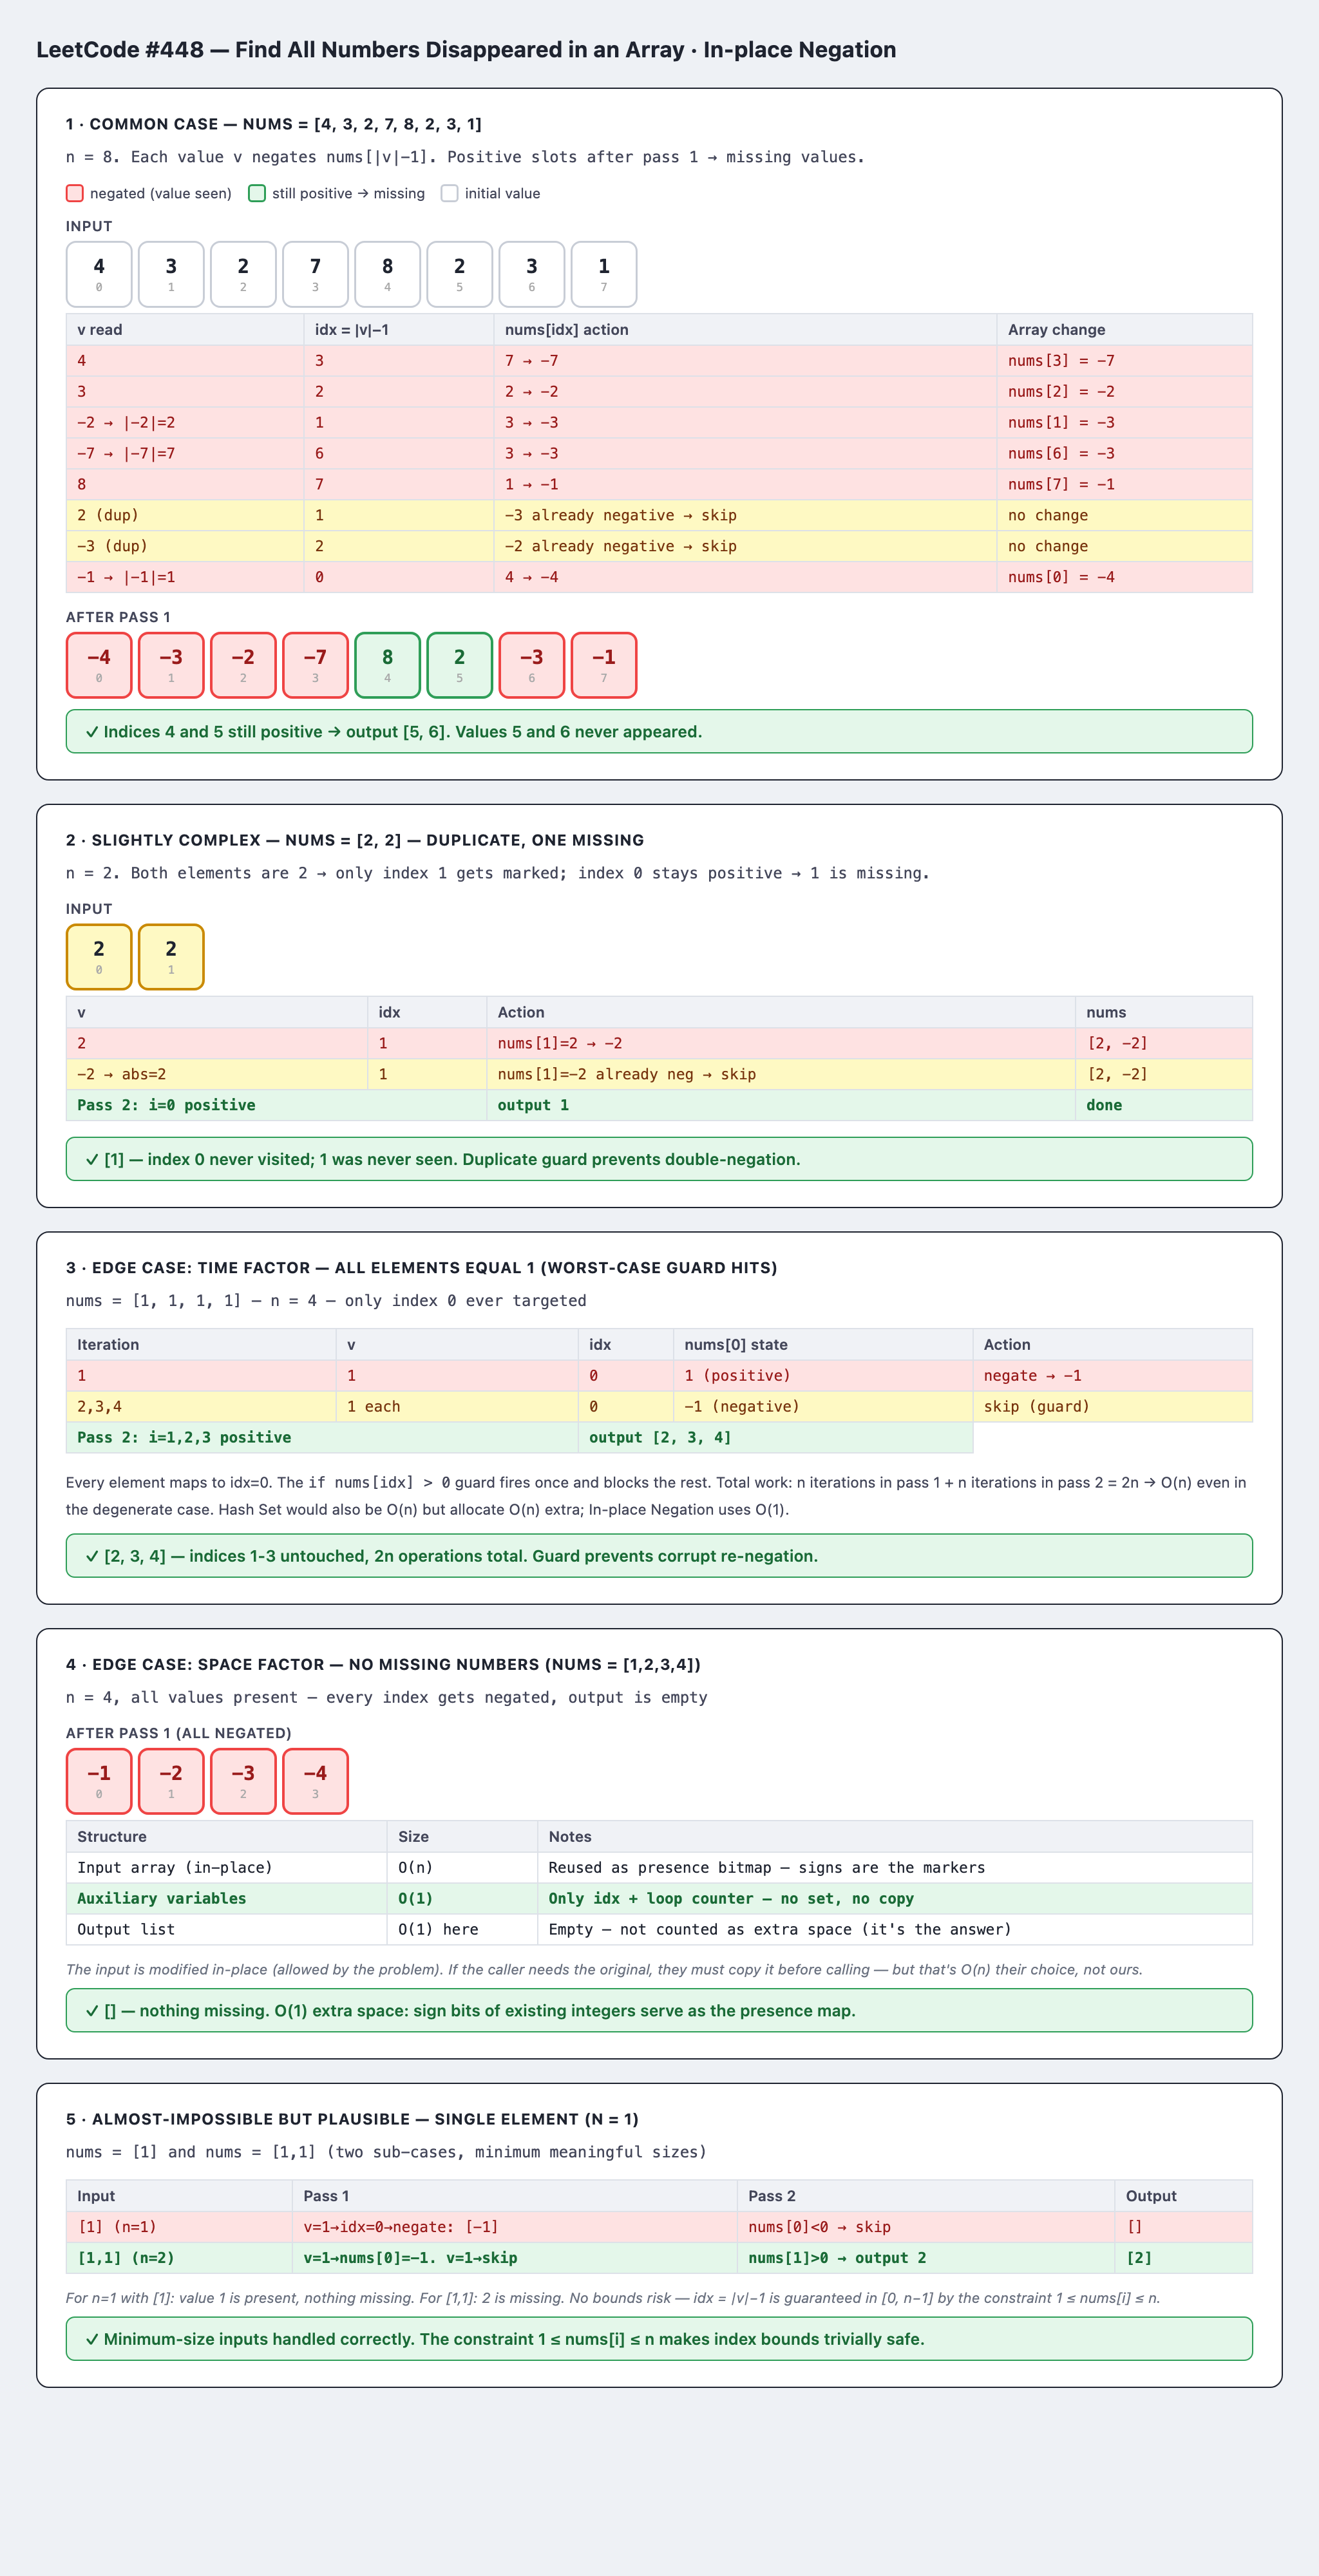